Hello students! This week task involves training an Autoencoder model for the image reconstruction task.

## Convolutional Autoencoder

Convolutional Auto-encoders are generally applied in applications of image reconstruction to minimize reconstruction errors by learning filters. Auto-encoders are trained in this task, they can be applied to any input in order to extract features, for example for data analysis such as clustering.

This article is very useful for understanding CNNs https://medium.com/thedeephub/convolutional-neural-networks-a-comprehensive-guide-5cc0b5eae175

https://www.youtube.com/watch?v=pj9-rr1wDhM

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data.sampler import SubsetRandomSampler
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
%matplotlib inline
import torch.nn as nn
import torch.nn.functional as F

/home/tmedi/.conda/envs/mar/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Download MNIST dataset

In [2]:
#Converting data to torch.FloatTensor
transform = transforms.ToTensor()

# Download the training and test datasets
train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)

test_data = datasets.MNIST(root='data', train=False, download=True, transform=transform)

Prepare the data loaders for training and testing.

In [3]:
train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, num_workers=0)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=32, num_workers=0)

Print random images from the training set.

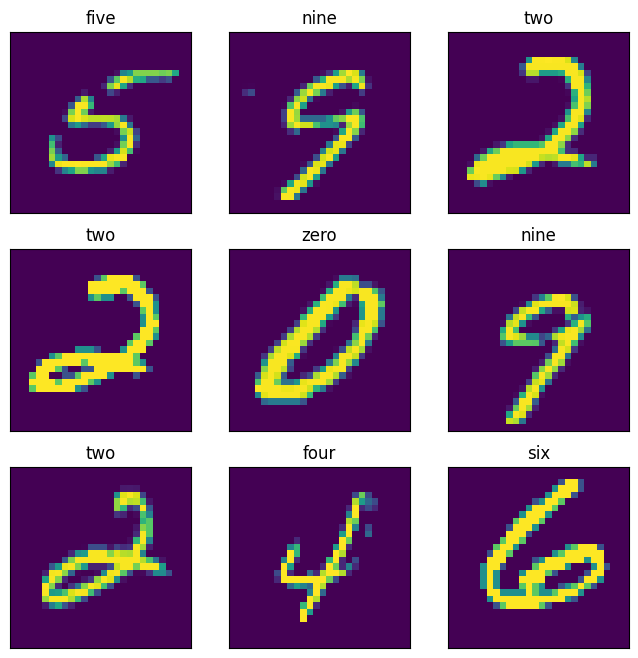

In [4]:
#Utility functions to un-normalize and display an image
def imshow(img):
    img = img / 2 + 0.5  
    plt.imshow(np.transpose(img, (1, 2, 0))) 

 
#Define the image classes
classes = ['zero','one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine']

#Obtain one batch of training images
dataiter = iter(train_loader)
#images, labels = dataiter
 # convert images to numpy for display
for images, labels in dataiter:
    images = images.numpy()
#Plot the images
fig = plt.figure(figsize=(8, 8))
# display 20 images
for idx in np.arange(9):
    ax = fig.add_subplot(3, 3, idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(classes[labels[idx]])

Define the Convolutional Autoencoder as a class 

In [5]:
#Define the Convolutional Autoencoder
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()
       
        #Encoder
        self.encoder = nn.Sequential(
           nn.Conv2d(1, 16, kernel_size=3, padding=1),
           nn.BatchNorm2d(16),
           nn.ReLU(),
           nn.MaxPool2d(2),

           nn.Conv2d(16, 8, kernel_size=3, padding=1),
           nn.BatchNorm2d(8),
           nn.ReLU(),
           nn.MaxPool2d(2),

           nn.Conv2d(8, 4, kernel_size=3, padding=1),
           nn.BatchNorm2d(4),
           nn.ReLU(),
       )
        
        self.decoder = nn.Sequential(

           nn.Conv2d(4, 8, kernel_size=3, padding=1),
           nn.BatchNorm2d(8),
           nn.ReLU(),

           nn.ConvTranspose2d(8, 16, kernel_size=2, stride=2),
           nn.BatchNorm2d(16),
           nn.ReLU(),

           nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2),
           nn.Sigmoid(),
       )


    def forward(self, x):
        z = self.encoder(x)
        x = self.decoder(z)
              
        return x


#Instantiate the model
model = ConvAutoencoder()
print(model)

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(8, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (decoder): Sequential(
    (0): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(8, 16, kernel_size=(2, 2

In [6]:
#Loss function
criterion = nn.BCELoss()

#Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [7]:
def get_device():
    if torch.cuda.is_available():
        device = 'cuda:0'
    else:
        device = 'cpu'
    return device

device = get_device()
print(device)
model.to(device)

cuda:0


ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(8, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (decoder): Sequential(
    (0): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(8, 16, kernel_size=(2, 2

# Train

In [8]:
#Epochs
n_epochs = 25 #increase this number if possible

for epoch in range(1, n_epochs+1):
    # monitor training loss
    train_loss = 0.0

    #Training
    for data in train_loader:
        images, _ = data
        images = images.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()*images.size(0)
          
    train_loss = train_loss/len(train_loader)
    print('Epoch: {} \tTraining Loss: {:.6f}'.format(epoch, train_loss))


Epoch: 1 	Training Loss: 4.717218
Epoch: 2 	Training Loss: 2.593812
Epoch: 3 	Training Loss: 2.527235
Epoch: 4 	Training Loss: 2.482281
Epoch: 5 	Training Loss: 2.454543
Epoch: 6 	Training Loss: 2.434608
Epoch: 7 	Training Loss: 2.415323
Epoch: 8 	Training Loss: 2.394215
Epoch: 9 	Training Loss: 2.376941
Epoch: 10 	Training Loss: 2.365218
Epoch: 11 	Training Loss: 2.354573
Epoch: 12 	Training Loss: 2.345655
Epoch: 13 	Training Loss: 2.338867
Epoch: 14 	Training Loss: 2.333225
Epoch: 15 	Training Loss: 2.328483
Epoch: 16 	Training Loss: 2.324312
Epoch: 17 	Training Loss: 2.320522
Epoch: 18 	Training Loss: 2.317185
Epoch: 19 	Training Loss: 2.314302
Epoch: 20 	Training Loss: 2.311740
Epoch: 21 	Training Loss: 2.309303
Epoch: 22 	Training Loss: 2.306948
Epoch: 23 	Training Loss: 2.304657
Epoch: 24 	Training Loss: 2.302529
Epoch: 25 	Training Loss: 2.300458


Original Images


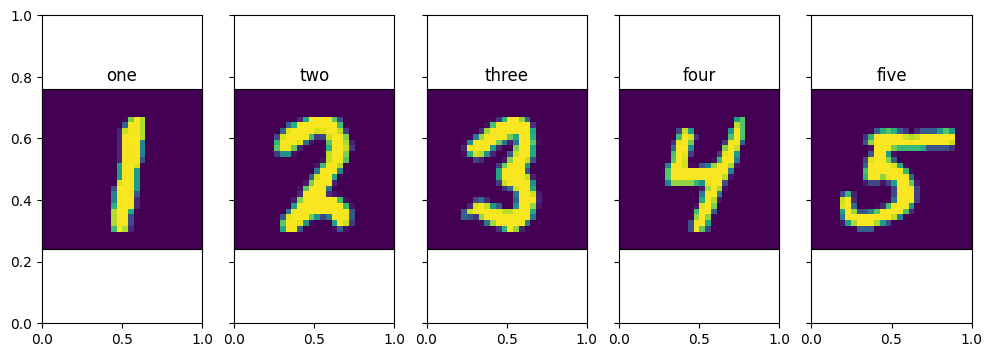

Reconstructed Images


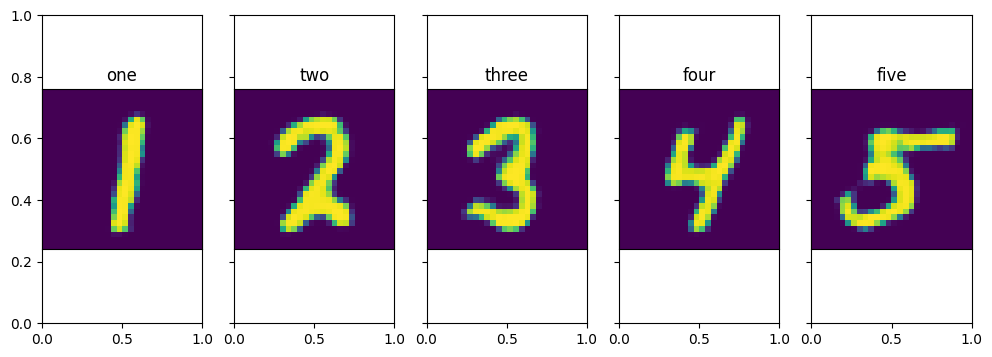

In [10]:
#Batch of test images
dataiter = iter(test_loader)
#images, labels = dataiter.next()
for images, labels in dataiter:
    images = images
    labels = labels
batch_size=16
model.eval()
#Sample outputs
output = model(images.cuda())
images = images.numpy()
output = output.view(batch_size, 1, 28, 28)
output = output.cpu().detach().numpy()

#Original Images
print("Original Images")
fig, axes = plt.subplots(nrows=1, ncols=5, sharex=True, sharey=True, figsize=(12,4))
for idx in np.arange(5):
    ax = fig.add_subplot(1, 5, idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(classes[labels[idx]])
plt.show()

#Reconstructed Images
print('Reconstructed Images')
fig, axes = plt.subplots(nrows=1, ncols=5, sharex=True, sharey=True, figsize=(12,4))
for idx in np.arange(5):
    ax = fig.add_subplot(1, 5, idx+1, xticks=[], yticks=[])
    imshow(output[idx])
    ax.set_title(classes[labels[idx]])
plt.show() 

tSNE plot

/tmp/ipykernel_1597490/4225363808.py:17: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(tsne_features[:, 0], tsne_features[:, 1], cmap='viridis')


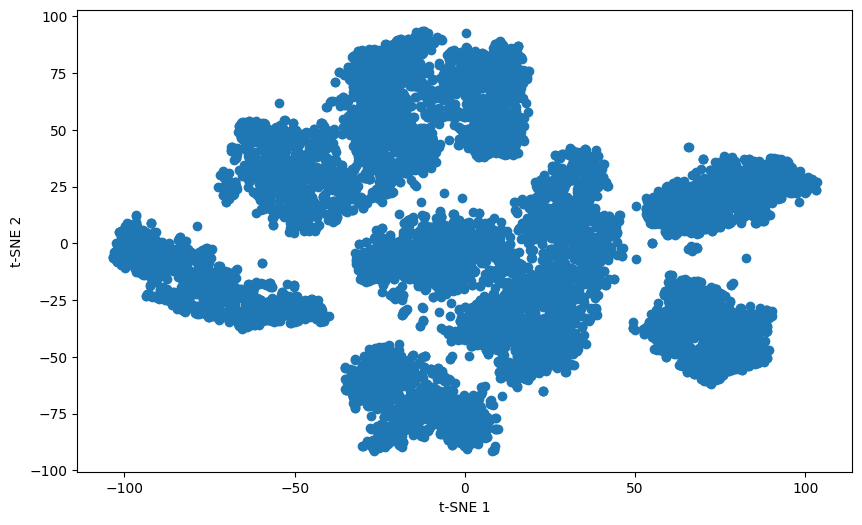

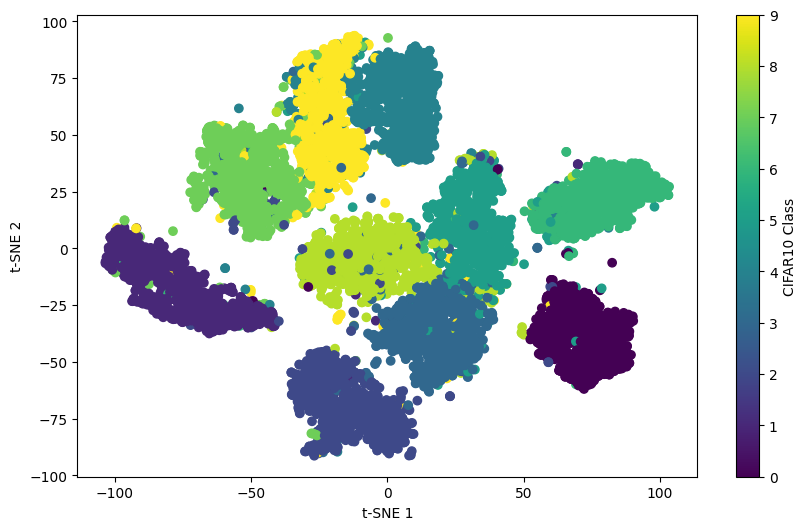

In [11]:
# Extract features using the trained autoencoder
from sklearn.manifold import TSNE
with torch.no_grad():
   features = []
   for i,(data, labels) in enumerate(test_loader):
       data = data.to(device)
       encoded = model.encoder(data)
       features.append(encoded.view(encoded.size(0), -1).cpu().numpy())
features = np.concatenate(features, axis=0)

# Apply TSNE for dimensionality reduction
tsne = TSNE(n_components=2, perplexity=33, learning_rate=1000, init='pca')
tsne_features = tsne.fit_transform(features)

# Plot the TSNE results without label
plt.figure(figsize=(10, 6))
plt.scatter(tsne_features[:, 0], tsne_features[:, 1], cmap='viridis')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

# Plot the TSNE results with label
plt.figure(figsize=(10, 6))
plt.scatter(tsne_features[:, 0], tsne_features[:, 1], c=test_data.targets, cmap='viridis')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.colorbar(label='CIFAR10 Class')
plt.show()

## Your Turn

1.What do you observe when training the Autoencoder for image reconstruction?

2.Where do the block-artifacts come from?

# TO DO

3.Improve the model performance & plot tSNE plot! (play around)

4.Modify to becomes a denoising auto-encoder!

1. When training the autoencoder with the above provided code:

    Training loss decreases over epochs, showing the model is learning.
    The reconstruction quality improves gradually, starting from blurry outputs to clearer ones.
    However, fine details or textures may still be missing, and reconstructions may appear blurry or smoothed.
    Sometimes, blocky artifacts (also called checkerboard artifacts) appear, especially around edges or fine structures.

2. Block artifacts in autoencoder outputs typically come from:

    Upsampling methods (like ConvTranspose2d) causing uneven overlaps in pixel generation.
    Kernel size/stride mismatches during the encoding-decoding process.
    Insufficient latent space, leading to poor capture of high-frequency details.
    Too shallow decoder, failing to generate fine-grained details.

In [9]:
# Increase epochs
n_epochs = 30  # More training time

Denoising AE

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Epochs
n_epochs = 30  # Increased as per your note!

for epoch in range(1, n_epochs + 1):
    train_loss = 0.0

    model.train()
    for data in train_loader:
        images, _ = data
        images = images.to(device)

        # Add noise to the input images
        noise = torch.randn_like(images) * 0.1  # Adjust noise level (0.1 works well)
        noisy_images = images + noise
        noisy_images = torch.clamp(noisy_images, 0., 1.)  # Keep pixel values in [0, 1]

        optimizer.zero_grad()
        
        # Feed the noisy images into the model
        outputs = model(noisy_images)

        # Compare the output with the original (clean) images
        loss = criterion(outputs, images)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss = train_loss / len(train_loader.dataset)
    print('Epoch: {} \tTraining Loss: {:.6f}'.format(epoch, train_loss))


Epoch: 1 	Training Loss: 0.004478
Epoch: 2 	Training Loss: 0.004350
Epoch: 3 	Training Loss: 0.004310
Epoch: 4 	Training Loss: 0.004280
Epoch: 5 	Training Loss: 0.004261
Epoch: 6 	Training Loss: 0.004248
Epoch: 7 	Training Loss: 0.004227
Epoch: 8 	Training Loss: 0.004215
Epoch: 9 	Training Loss: 0.004204
Epoch: 10 	Training Loss: 0.004191
Epoch: 11 	Training Loss: 0.004177
Epoch: 12 	Training Loss: 0.004172
Epoch: 13 	Training Loss: 0.004162
Epoch: 14 	Training Loss: 0.004156
Epoch: 15 	Training Loss: 0.004147
Epoch: 16 	Training Loss: 0.004139
Epoch: 17 	Training Loss: 0.004129
Epoch: 18 	Training Loss: 0.004124
Epoch: 19 	Training Loss: 0.004113
Epoch: 20 	Training Loss: 0.004105
Epoch: 21 	Training Loss: 0.004098
Epoch: 22 	Training Loss: 0.004088
Epoch: 23 	Training Loss: 0.004081
Epoch: 24 	Training Loss: 0.004072
Epoch: 25 	Training Loss: 0.004066
Epoch: 26 	Training Loss: 0.004061
Epoch: 27 	Training Loss: 0.004055
Epoch: 28 	Training Loss: 0.004046
Epoch: 29 	Training Loss: 0.0

Original Images (Clean)


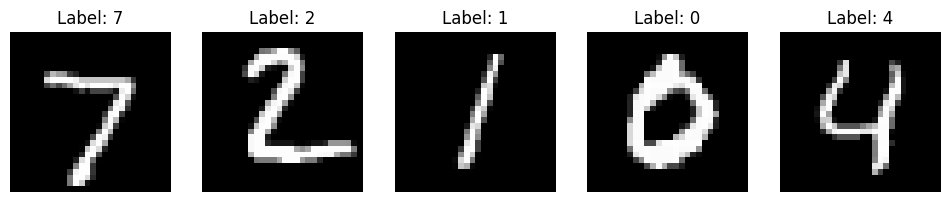

Noisy Images


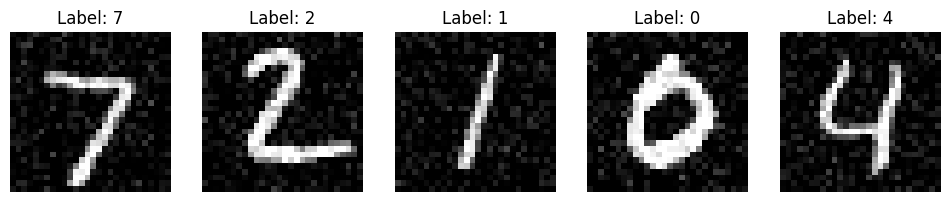

Denoised (Reconstructed) Images


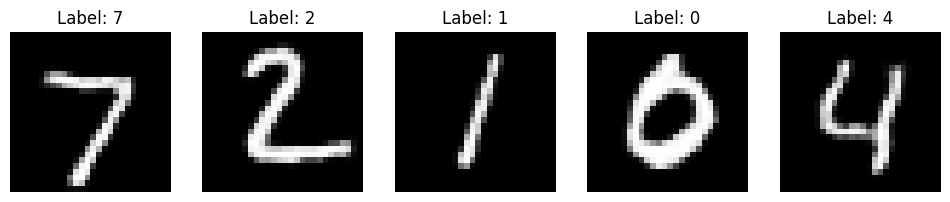

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Helper function for showing images
def imshow(img):
    img = np.squeeze(img)
    plt.imshow(img, cmap='gray')

model.eval()

# Get a batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)
images = images.to(device)

# Add noise
noise = torch.randn_like(images) * 0.1
noisy_images = images + noise
noisy_images = torch.clamp(noisy_images, 0., 1.)

# Denoising
with torch.no_grad():
    outputs = model(noisy_images)

# Move tensors to CPU
images = images.cpu().numpy()
noisy_images = noisy_images.cpu().numpy()
outputs = outputs.cpu().numpy()

batch_size = images.shape[0]  # Get the actual batch size

# Original Images
print("Original Images (Clean)")
fig, axes = plt.subplots(1, 5, figsize=(12, 4))
for idx in range(5):
    ax = axes[idx]
    img = np.squeeze(images[idx])
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {labels[idx].item()}")
    ax.axis('off')
plt.show()

# Noisy Images
print("Noisy Images")
fig, axes = plt.subplots(1, 5, figsize=(12, 4))
for idx in range(5):
    ax = axes[idx]
    img = np.squeeze(noisy_images[idx])
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {labels[idx].item()}")
    ax.axis('off')
plt.show()

# Denoised (Reconstructed) Images
print("Denoised (Reconstructed) Images")
fig, axes = plt.subplots(1, 5, figsize=(12, 4))
for idx in range(5):
    ax = axes[idx]
    img = np.squeeze(outputs[idx])
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {labels[idx].item()}")
    ax.axis('off')
plt.show()


